权重衰退适用于模型发生过拟合的情况.假设我们的模型为一个MLP,一种想法是对其模型层数和层数之间的单元数进行约束,另一种想法则是对其参数的范围进行约束,而权重衰退就是对其参数的范围进行约束.

具体而言,对于一个classic的梯度下降过程,我们要同时保证
$$
\min L(\mathbf{w},\mathbf{b}),\Vert w \Vert_2\leq \theta
$$

而对于上述过程,对于每一个$\theta$而言都能找到一个$\lambda$使得原优化条件等价与下述目标函数(利用拉格朗日乘子法可证明)

$$
\min L(\mathbf{w},\mathbf{b})+\frac{1}{2}\lambda \Vert w\Vert_2^2
$$

其中$\lambda$作为权重衰退的超参数,其值越大,则模型越不容易发生过拟合.

权重衰退中更新参数的过程我们通过以下操作实现:

$$
\frac{\partial }{\partial \mathbf{w}}(L(\mathbf{w},\mathbf{b})+\frac{1}{2}\lambda \Vert w\Vert_2^2)=\frac{\partial L}{\partial \mathbf{w}}+\lambda\mathbf{w}\\
\mathbf{w}_{t+1}=\mathbf{w}_t-\eta\frac{\partial }{\partial \mathbf{w}_t}(L(\mathbf{w}_t,\mathbf{b})+\frac{1}{2}\lambda \Vert w\Vert_2^2)=(1-\eta\lambda)\mathbf{w}_{t}-\eta\frac{\partial L}{\partial \mathbf{w_t}}
$$

In [97]:
import numpy as np
import torch
from torch.utils import data as Data
from d2l import torch as d2l

In [98]:
n_train=100
n_test=100
num_inputs=200
batch_sizes=10

true_w,true_b=torch.ones(num_inputs,1)*0.01, 0.05

train_data=d2l.synthetic_data(true_w,true_b,n_train)
train_iter=d2l.load_array(train_data,batch_size=batch_sizes,is_train=True)
test_data=d2l.synthetic_data(true_w,true_b,n_test)
test_iter=d2l.load_array(test_data,batch_size=batch_sizes,is_train=False)   


In [99]:
import torch.nn as nn
import torch.optim as optim

net=nn.Sequential(nn.Linear(200,1))

In [100]:
net[0].weight.data.normal_(0, 0.1)
net[0].bias.data.fill_(0)

print (net[0].weight)

Parameter containing:
tensor([[ 0.0259,  0.1378,  0.0313,  0.0193, -0.0375,  0.0327, -0.0455, -0.0808,
         -0.0005,  0.0641, -0.0135,  0.0092,  0.0055,  0.1030,  0.1301,  0.0444,
          0.0776,  0.1501, -0.1775, -0.1417,  0.1992, -0.1877, -0.0952, -0.0655,
          0.0367,  0.0382, -0.1489, -0.0531, -0.0600, -0.0568, -0.0066,  0.0955,
          0.1724, -0.2028, -0.0154, -0.0616, -0.0383, -0.1512, -0.0875, -0.0648,
          0.0396, -0.1112, -0.0579, -0.0378, -0.1290,  0.0435,  0.0737,  0.0015,
          0.0742,  0.0045, -0.0134,  0.1006, -0.0192,  0.0966, -0.0874,  0.0888,
          0.0514,  0.1245,  0.0869,  0.0534,  0.0012,  0.0989,  0.2260, -0.0705,
          0.0389, -0.0702, -0.0830, -0.0562,  0.1756,  0.1538, -0.0217,  0.2377,
          0.1138,  0.0244, -0.0928, -0.2021, -0.0190, -0.0753,  0.1743, -0.0959,
          0.0630, -0.2459,  0.0417,  0.0543,  0.0043,  0.1489,  0.1127, -0.0227,
         -0.0134,  0.0031, -0.0803,  0.0430,  0.1521, -0.0526, -0.1860, -0.0105,
      

In [101]:
loss=nn.MSELoss()

In [102]:
def L2(w,lbd):
    return 0.5*lbd*torch.sum(w.pow(2))

L2(net[0].weight.data,1)
def evaluate_loss(net, data_iter, loss):  #@save
    """评估给定数据集上模型的损失"""
    metric = d2l.Accumulator(2)  # 损失的总和,样本数量
    for X, y in data_iter:
        out = net(X)
        y = y.reshape(out.shape)
        l = loss(out, y)
        metric.add(l.sum(), l.numel())
    return metric[0] / metric[1]

def train_regression(learning_rate,lbd,num_epochs=100):
    trainer = torch.optim.SGD(net.parameters(), lr=learning_rate)
    animator = d2l.Animator(xlabel='epoch', ylabel='loss', yscale='log',
                            xlim=[1, num_epochs], ylim=[1e-3, 1e2],
                            legend=['train', 'test'])
    for epoch in range(num_epochs):
        for X, y in train_iter:
            # Compute gradients and update parameters
            y_hat = net(X)
            l = loss(y_hat, y)+L2(net[0].weight,lbd)
            #error_example
            #l=loss(y_hat,y)+L2(net[0].weight.data,lbd) 
            # 使用 .data 会从计算图中分离张量，导致梯度无法回传，正则化项对权重更新没有影响。
            if isinstance(trainer, torch.optim.Optimizer):
                # Using PyTorch built-in optimizer and loss criterion
                trainer.zero_grad()
                l.mean().backward()
                trainer.step()
            else:
                # Using custom updater in Chapter 3 (minibatch stochastic gradient descent)
                l.sum().backward()
                trainer(X.shape[0])
            if epoch == 0 or (epoch + 1) % 20 == 0:
                animator.add(epoch + 1, (evaluate_loss(net, train_iter, loss),
                                        evaluate_loss(net, test_iter, loss)))
    print('w的L2范数是', torch.norm(net[0].weight.data))
    
    

w的L2范数是 tensor(0.0593)


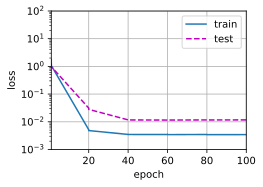

In [103]:
train_regression(0.003,3)

In [104]:
def train_regression_concise(learning_rate,lbd,num_epochs=100):
    for param in net.parameters(): 
        param.data.normal_(0, 0.01)
    trainer = torch.optim.SGD([{'params':net[0].weight, 'weight_decay':lbd,'params':net[0].bias}], lr=learning_rate)
    animator = d2l.Animator(xlabel='epoch', ylabel='loss', yscale='log',
                            xlim=[1, num_epochs], ylim=[1e-3, 1e2],
                            legend=['train', 'test'])
    for epoch in range(num_epochs):
        for X, y in train_iter:
            # Compute gradients and update parameters
            y_hat = net(X)
            l = loss(y_hat, y)+L2(net[0].weight,lbd)
            #error_example
            #l=loss(y_hat,y)+L2(net[0].weight.data,lbd) 
            # 使用 .data 会从计算图中分离张量，导致梯度无法回传，正则化项对权重更新没有影响。
            if isinstance(trainer, torch.optim.Optimizer):
                # Using PyTorch built-in optimizer and loss criterion
                trainer.zero_grad()
                l.mean().backward()
                trainer.step()
            else:
                # Using custom updater in Chapter 3 (minibatch stochastic gradient descent)
                l.sum().backward()
                trainer(X.shape[0])
            if epoch == 0 or (epoch + 1) % 20 == 0:
                animator.add(epoch + 1, (evaluate_loss(net, train_iter, loss),
                                        evaluate_loss(net, test_iter, loss)))
    print('w的L2范数是', torch.norm(net[0].weight.data))
    

w的L2范数是 tensor(0.0594)


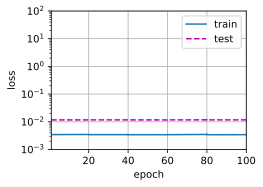

In [105]:
train_regression(0.003,3)